<h1 style="font-size:3rem;color:blue;">Snusbruk blandt unge unge fra 16 - 24 år over tid (API) </h1>

In [2]:
pip install pandas matplotlib pyjstat

     ---------------------------------------- 0.0/798.0 kB ? eta -:--:--
     ---- ---------------------------------- 92.2/798.0 kB 1.7 MB/s eta 0:00:01
     ------------- ------------------------ 276.5/798.0 kB 2.9 MB/s eta 0:00:01
     ----------------------------- -------- 614.4/798.0 kB 3.9 MB/s eta 0:00:01
     -------------------------------------- 798.0/798.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pyjstat: filename=pyjstat-2.4.0-py3-none-any.whl size=22799 sha256=0cc828c2c745a4d891cb51e36794a6716da9365acac11c32daf878749b4bd6b2
  Stored in directory: c:\users\haava\appdata\local\pip\cache\wheels\d7\b0\ac\350c026feabb6a22b2a5b3fb1f694e724c0f57c2c43ccaf738
Successfully built pyjstat
Note: you may need to restart the kernel to use updated packages.


<Response [200]>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   kjønn               18 non-null     object
 1   alder               18 non-null     object
 2   statistikkvariabel  18 non-null     object
 3   år                  18 non-null     object
 4   value               18 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 852.0+ bytes


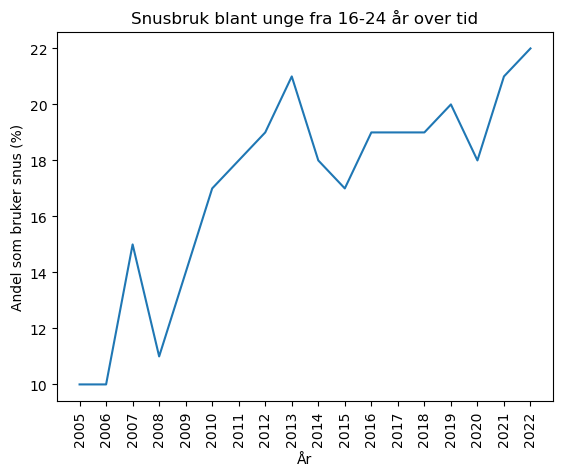

In [3]:
# Import av dataanalyse
import pandas as pd
import matplotlib.pyplot as plt
from pyjstat import pyjstat
import requests

# Basert på SSB sin oppskrift for å hente statestikk data:
# https://www.ssb.no/api/pxwebapi/api-eksempler-pa-kode/post-api-sporring-med-json-stat-og-fa-pandas-dataframe-i-retur


# Tabell 07692: Daglig snusbrukere og av-og-til-snusbrukere (prosent), etter statistikkvariabel, kjønn, alder og år:
# https://www.ssb.no/statbank/table/07692/tableViewLayout1/

# API-spørringen for denne tabellen

# (1) URL:
POST_URL = 'https://data.ssb.no/api/v0/no/table/07692/'
# (2) JSON-spørring:
payload = {
  "query": [
    {
      "code": "Kjonn",
      "selection": {
        "filter": "item",
        "values": [
          "0"
        ]
      }
    },
    {
      "code": "Alder",
      "selection": {
        "filter": "item",
        "values": [
          "16-24"
        ]
      }
    },
    {
      "code": "ContentsCode",
      "selection": {
        "filter": "item",
        "values": [
          "Dagroyk"
        ]
      }
    }
  ],
  "response": {
    "format": "json-stat2"
  }
}

# Sending av spørring 
resultat = requests.post(POST_URL, json = payload)

print(resultat)

# Leser ut JSON-stat dataset fra responsen til spørringen
dataset = pyjstat.Dataset.read(resultat.text)

# Gjør om JSON-start dataset til pandas dataframe (a.k.a data serialisering)
df = dataset.write('dataframe') 

df.head() # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html
df.tail() # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.tail.html
df.info() # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html

# Plott av snusbruk over tid
plt.plot(df['år'], df['value'])
plt.xlabel('År')
plt.xticks(rotation=90)
plt.ylabel('Andel som bruker snus (%)')
plt.title('Snusbruk blant unge fra 16-24 år over tid')
plt.show()




Problemstilling: En undersøkelse av endringer i snusingens utbredelse fra 2005 til 2022: Hvorvidt andelen mennesker som snuser har økt i aldersgruppen unge voksne (16-24 år)

I motsetning til forrige oppgave er jeg nå på jakt etter endringen av snusbruk blandt unge i perioden 2005 til 2022. Dette fordi ved bruk API kan man lett hente ut et større datasett.

Dette programmet bekrefter min misstanke om at bruken av snus blandt unge har økt siden 2005 (det har nærmest hatt en dobbling). 